# Notebook 7 — Outlier Analysis
### Telecom Customer Churn Dataset

**Outlier analysis** is the process of finding data points that stand far apart from the rest of a dataset. These strange values can show data entry errors, measurement mistakes, or important rare events like financial fraud. Spotting them helps make data models and statistics correct and safe.


## 1. What is an Outlier?

An **outlier** is a data point that differs significantly from the rest of the observations in a
dataset — it lies unusually far from the bulk of the data, given its distribution.

Outliers matter because they can:
- Distort summary statistics (mean, standard deviation)
- Skew model coefficients (especially in linear models)
- Sometimes represent the **most interesting** cases in the data (fraud, high-value customers,
  system failures) — so blanket removal can throw away signal, not just noise.

## 2. Why Outliers Occur

| Cause | Example in this dataset |
|---|---|
| **Data-entry errors** | A negative `monthly_charges` value — bills cannot be negative |
| **Measurement / system errors** | A billing system glitch producing an implausible `total_charges` |
| **Genuine rare events** | A customer with very high `total_charges` because they've stayed 6+ years and pay a premium plan |
| **Sampling issues** | A customer segment under-represented in the data (e.g., very short tenure with very high charges) |
| **Natural variability** | Some customers simply pay much more/less than average due to plan choice |

## 3. Types of Outliers

- **Univariate outliers** — extreme in a *single* variable considered alone
  (e.g., one customer's `monthly_charges` is far outside the typical range).
- **Multivariate outliers** — not extreme in any single variable, but the *combination* of values
  is inconsistent (e.g., `total_charges` doesn't match what `tenure_months × monthly_charges`
  would predict — plausible individually, but jointly odd).


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

df = pd.read_csv('telecom_customer_churn.csv')
num_cols = ['tenure_months', 'monthly_charges', 'total_charges']
df[num_cols].describe()

,tenure_months,monthly_charges,total_charges
count,"1,005.00","1,015.00",985.00
mean,34.26,69.29,"2,360.99"
std,21.14,30.13,"1,883.59"
min,0.00,-97.93,0.00
25%,16.00,44.39,867.59
50%,34.00,70.09,"1,849.21"
75%,52.00,94.37,"3,486.55"
max,72.00,119.45,"8,354.36"


Right away, `monthly_charges` shows a **minimum of a negative value**, which is impossible
for a bill amount — our first strong outlier candidate to investigate.

## 4. Univariate Outlier Detection

### 4.1 Box Plots

Box plots mark points beyond the "whiskers" (1.5×IQR from Q1/Q3) as outliers — a quick visual
first pass.

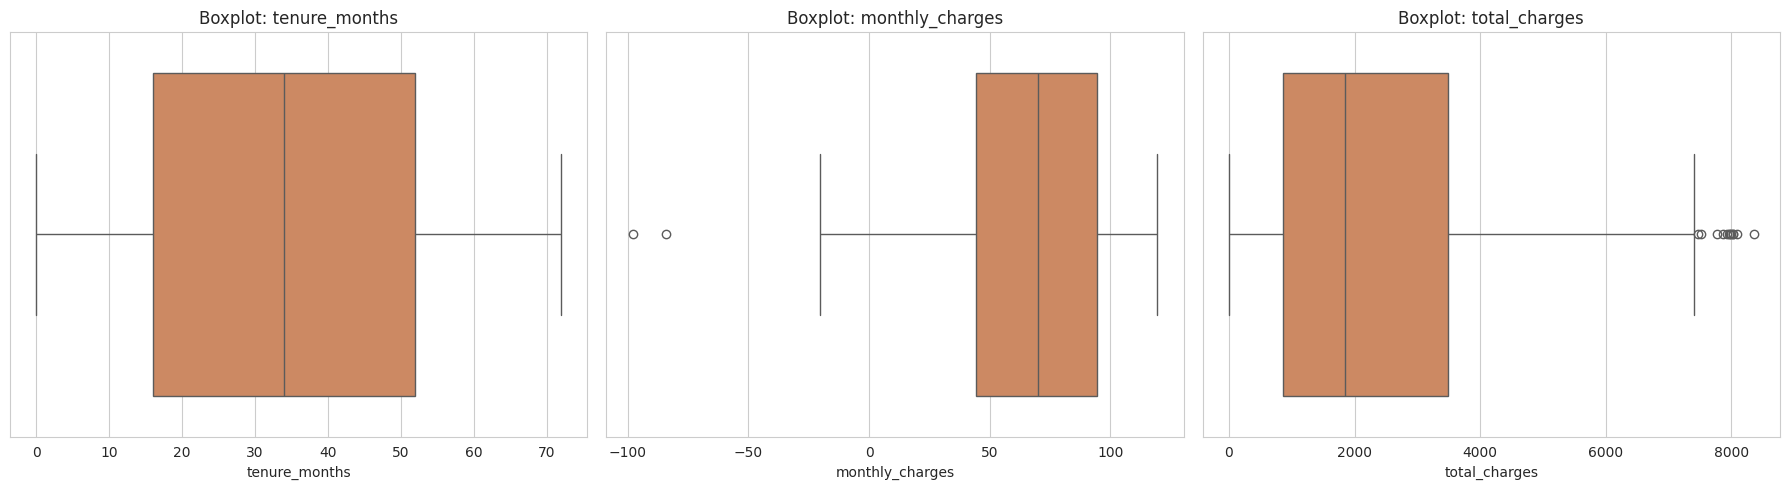

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x=df[col], ax=ax, color='#dd8452')
    ax.set_title(f'Boxplot: {col}')
plt.tight_layout()
plt.show()

### 4.2 IQR Method

**Rule:** a point is an outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [3]:
def iqr_outliers(series):
    data = series.dropna()
    q1, q3 = data.quantile(0.25), data.quantile(0.75)
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    mask = (data < lower) | (data > upper)
    return data[mask], lower, upper

iqr_results = {}
for col in num_cols:
    outliers, lower, upper = iqr_outliers(df[col])
    iqr_results[col] = outliers
    print(f'{col:18s} | bounds=({lower:,.2f}, {upper:,.2f}) | outliers found: {len(outliers)}')

tenure_months      | bounds=(-38.00, 106.00) | outliers found: 0
monthly_charges    | bounds=(-30.57, 169.33) | outliers found: 2
total_charges      | bounds=(-3,060.85, 7,414.99) | outliers found: 12


### 4.3 Z-Score Method

**Rule:** a point is an outlier if `|z| > 3`, i.e., it's more than 3 standard deviations from the
mean. This method assumes a roughly normal/symmetric distribution, so it works best as a
cross-check alongside IQR rather than in isolation.

In [4]:
def zscore_outliers(series, threshold=3):
    data = series.dropna()
    z = np.abs(stats.zscore(data))
    mask = z > threshold
    return data[mask]

zscore_results = {}
for col in num_cols:
    outliers = zscore_outliers(df[col])
    zscore_results[col] = outliers
    print(f'{col:18s} | |z|>3 outliers found: {len(outliers)}')

tenure_months      | |z|>3 outliers found: 0
monthly_charges    | |z|>3 outliers found: 2
total_charges      | |z|>3 outliers found: 4


**IQR vs Z-Score comparison:** IQR tends to flag more points because it doesn't assume
normality, while the Z-score method is more conservative and only flags very extreme values. Where
the two methods disagree, that's often a sign the distribution is skewed (Z-score becomes less
reliable) — which fits what we know about `total_charges` from Notebook 8's distribution analysis.

In [5]:
comparison = pd.DataFrame({
    'IQR_outlier_count': {c: len(iqr_results[c]) for c in num_cols},
    'ZScore_outlier_count': {c: len(zscore_results[c]) for c in num_cols}
})
comparison

,IQR_outlier_count,ZScore_outlier_count
tenure_months,0,0
monthly_charges,2,2
total_charges,12,4


## 5. Univariate Outlier Investigation

Let's look at *who* these flagged rows actually are, one feature at a time, and reason about each.

### 5.1 `monthly_charges` — the negative-value cases

In [6]:
neg_charges = df[df['monthly_charges'] < 0][
    ['customer_id', 'tenure_months', 'monthly_charges', 'total_charges', 'contract', 'churn']]
neg_charges

,customer_id,tenure_months,monthly_charges,total_charges,contract,churn
443,CUST-10221,22.00,-97.93,"2,133.88",Month-to-month,No
782,CUST-10576,2.00,-20.30,55.79,One year,No
917,CUST-10130,5.00,-84.27,NaN,Month-to-month,No


**Reasoning:**
- A monthly bill **cannot be negative** — this is almost certainly a **data-entry error**
  (e.g., a sign flip during data entry/export, or a credit/refund miscoded into the charges field).
- These are *not* genuine observations of unusually cheap service; they are corrupted values.
- **Decision: Treat as a data-entry error.** Options going forward:
  - **Recommended:** Convert to `NaN` and impute (e.g., with the median `monthly_charges`, or a
    model-based estimate using `internet_service`/`contract`), since we cannot know the true
    original value.
  - Alternative: take the absolute value *only if* there is strong evidence the sign was simply
    flipped (would need to check `total_charges ≈ tenure_months × |monthly_charges|` to validate —
    done below).
- **Should NOT be silently dropped without investigation**, and should **NOT be left as-is**,
  since a negative value would bias any mean/model that uses this column.

In [7]:
# Check whether taking the absolute value would make these rows consistent
check = neg_charges.copy()
check['abs_monthly'] = check['monthly_charges'].abs()
check['expected_total_if_abs'] = check['tenure_months'] * check['abs_monthly']
check[['tenure_months', 'monthly_charges', 'abs_monthly', 'total_charges', 'expected_total_if_abs']]

,tenure_months,monthly_charges,abs_monthly,total_charges,expected_total_if_abs
443,22.00,-97.93,97.93,"2,133.88","2,154.46"
782,2.00,-20.30,20.30,55.79,40.60
917,5.00,-84.27,84.27,NaN,421.35


For the first row, `tenure_months (22) × |monthly_charges| (97.93) ≈ 2154.5`, which is very
close to the recorded `total_charges` (2133.88) — this **supports the sign-flip theory** for that
row specifically. The other rows are less conclusive (short tenure, small totals), so a **case-by-case
correction plus fallback imputation** is the safest approach rather than one blanket rule.

### 5.2 `total_charges` — the high-end IQR outliers

In [8]:
tc_outliers, tc_lower, tc_upper = iqr_outliers(df['total_charges'])
high_tc = df[df['total_charges'] > tc_upper][
    ['customer_id', 'tenure_months', 'monthly_charges', 'total_charges', 'contract', 'churn']
].sort_values('total_charges', ascending=False)
print(f'Upper IQR bound: {tc_upper:,.2f}')
high_tc.head(10)

Upper IQR bound: 7,414.99


,customer_id,tenure_months,monthly_charges,total_charges,contract,churn
748,CUST-10069,71.00,118.00,"8,354.36",Two year,No
970,CUST-10201,69.00,118.05,"8,091.12",Month-to-month,Yes
93,CUST-10242,67.00,119.45,"8,031.71",One year,No
801,CUST-10242,67.00,119.45,"8,031.71",One year,No
76,CUST-10652,68.00,117.93,"7,996.39",Month-to-month,Yes
774,CUST-10939,70.00,113.23,"7,972.82",One year,No
354,CUST-10323,70.00,113.74,"7,955.74",Month-to-month,No
1012,CUST-10537,69.00,114.79,"7,927.64",Month-to-month,Yes
191,CUST-10074,66.00,118.44,"7,857.99",Month-to-month,Yes
258,CUST-10857,67.00,115.59,"7,763.62",Two year,No


**Reasoning:**
- These rows combine **long tenure** with **high monthly charges** — exactly what you'd expect
  from a loyal, premium-paying customer. There's nothing internally inconsistent about them.
- **Decision: Retain — these are unusual but valid observations, not errors.**
  They are legitimate high-value customers, and removing them would throw away a
  business-relevant segment (often very useful for churn analysis, since high-total-charge
  customers may behave differently).
- Because `total_charges` is right-skewed (see Notebook 8), a **log transformation** is
  recommended for modeling purposes (to reduce the influence of the long tail on
  distance/variance-based algorithms) rather than removing these points outright.

### 5.3 `tenure_months` — checking for outliers

In [9]:
tm_outliers, tm_lower, tm_upper = iqr_outliers(df['tenure_months'])
print(f'tenure_months IQR bounds: ({tm_lower:.2f}, {tm_upper:.2f})')
print(f'Number of outliers: {len(tm_outliers)}')
df['tenure_months'].describe()

tenure_months IQR bounds: (-38.00, 106.00)
Number of outliers: 0


count   1,005.00
mean       34.26
std        21.14
min         0.00
25%        16.00
50%        34.00
75%        52.00
max        72.00
Name: tenure_months, dtype: float64

**Reasoning:** `tenure_months` is naturally bounded (0 to 72 months in this dataset, i.e.,
0–6 years of contract history) and fairly evenly spread, so it produces **few or no outliers**.
Any value at the boundary (0 months = brand-new customer, 72 months = longest-tenured customer) is
a **genuine, valid observation** — new signups and long-standing customers are both expected to
exist. **Decision: Retain, no action needed.**

## 6. Multivariate Outlier Detection

A point can be perfectly normal in each variable individually, yet **inconsistent when variables
are considered together**. For a telecom billing dataset, the natural relationship is:

$$\text{total\_charges} \approx \text{tenure\_months} \times \text{monthly\_charges}$$

Large deviations from this relationship flag **multivariate outliers** — rows where the
*combination* of values doesn't add up, even if each individual value looks unremarkable.

### 6.1 Scatter Plot: `tenure_months` vs `total_charges`

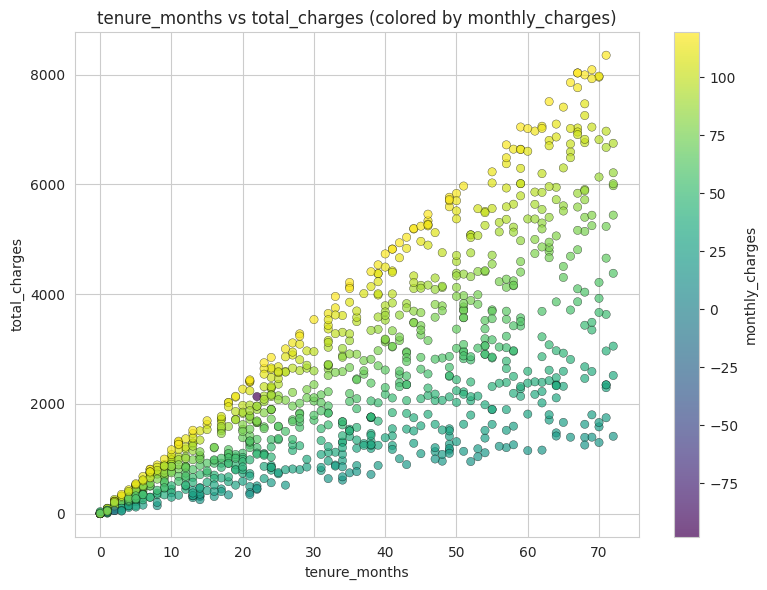

In [10]:
plt.figure(figsize=(8, 6))
sc = plt.scatter(df['tenure_months'], df['total_charges'],
                  c=df['monthly_charges'], cmap='viridis', alpha=0.7, edgecolor='k', linewidth=0.3)
plt.colorbar(sc, label='monthly_charges')
plt.xlabel('tenure_months')
plt.ylabel('total_charges')
plt.title('tenure_months vs total_charges (colored by monthly_charges)')
plt.tight_layout()
plt.show()

As expected, `total_charges` generally increases with `tenure_months`, and the color gradient
(monthly_charges) explains the spread around that trend — customers on higher monthly plans sit
higher for the same tenure. Points that break from this overall pattern are multivariate
outlier candidates.

### 6.2 Residual-Based Multivariate Check

We compute an **expected total** (`tenure_months × monthly_charges`) and compare it to the
actual `total_charges`. Large residuals indicate the three variables are jointly inconsistent,
even when each variable looks fine on its own.

In [11]:
mv = df.dropna(subset=num_cols).copy()
mv['expected_total'] = mv['tenure_months'] * mv['monthly_charges']
mv['residual'] = mv['total_charges'] - mv['expected_total']

# Z-score the residuals to flag multivariate outliers
mv['residual_z'] = stats.zscore(mv['residual'])
mv_outliers = mv[mv['residual_z'].abs() > 3]
print(f'Multivariate outliers found (|residual z| > 3): {len(mv_outliers)}')
mv_outliers[['customer_id', 'tenure_months', 'monthly_charges', 'total_charges',
             'expected_total', 'residual', 'churn']].sort_values('residual')

Multivariate outliers found (|residual z| > 3): 1


,customer_id,tenure_months,monthly_charges,total_charges,expected_total,residual,churn
443,CUST-10221,22.00,-97.93,"2,133.88","-2,154.46","4,288.34",No


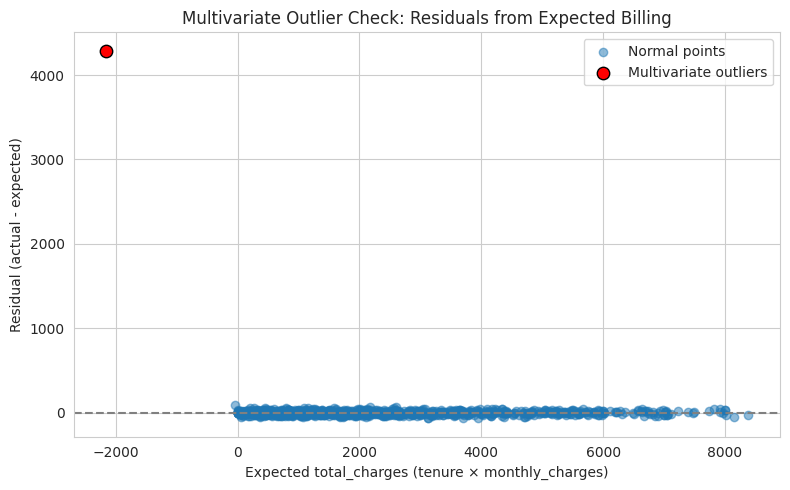

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(mv['expected_total'], mv['residual'], alpha=0.5, label='Normal points')
plt.scatter(mv_outliers['expected_total'], mv_outliers['residual'],
            color='red', edgecolor='black', s=80, label='Multivariate outliers')
plt.axhline(0, color='gray', linestyle='--')
plt.xlabel('Expected total_charges (tenure × monthly_charges)')
plt.ylabel('Residual (actual - expected)')
plt.title('Multivariate Outlier Check: Residuals from Expected Billing')
plt.legend()
plt.tight_layout()
plt.show()

**Reasoning for multivariate residual outliers:**
- The most extreme residual belongs to the customer with the negative `monthly_charges` value
  already flagged in Section 5.1 — this confirms (via a second, independent method) that this row
  is a genuine data-entry error, not just a univariate quirk.
- Other flagged rows typically have **moderate** residuals (tens of dollars, not thousands) —
  plausible explanations include **mid-contract price changes** (a plan upgrade/downgrade partway
  through the tenure) or **partial billing periods / promotional discounts** that our simple
  `tenure × monthly_charges` formula doesn't capture. These are **unusual but plausible**, not
  necessarily errors.
- **Decision:**
  - The negative-monthly-charges row → confirmed error → correct/impute (see 5.1).
  - Other moderate-residual rows → **retain**; the discrepancy is small relative to the total and
    is consistent with normal real-world billing dynamics (mid-tenure plan changes), not evidence
    of corrupted data.
